# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [3]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [4]:
# Load training dataset only
DATA_PATH = r"D:\Churn Prediction And Analysis Project\Cell2Cell Data\cell2celltrain.csv"
df = pd.read_csv(DATA_PATH)
df.head().T

,0,1,2,3,4
CustomerID,3000002,3000010,3000014,3000022,3000026
Churn,Yes,Yes,No,No,Yes
MonthlyRevenue,24.0,16.99,38.0,82.28,17.14
MonthlyMinutes,219.0,10.0,8.0,1312.0,0.0
TotalRecurringCharge,22.0,17.0,38.0,75.0,17.0
DirectorAssistedCalls,0.25,0.0,0.0,1.24,0.0
OverageMinutes,0.0,0.0,0.0,0.0,0.0
RoamingCalls,0.0,0.0,0.0,0.0,0.0
PercChangeMinutes,-157.0,-4.0,-2.0,157.0,0.0
PercChangeRevenues,-19.0,0.0,0.0,8.1,-0.2


In [34]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
# Display 5 random sample rows
print("Random 5 sample rows:")
df.sample(5).T


Dataset shape: 51047 rows x 59 columns
Random 5 sample rows:


,27122,33331,39554,27552,35183
CustomerID,3214478,3265530,3315326,3218074,3280874
Churn,Yes,Yes,No,No,No
MonthlyRevenue,56.15,45.16,32.55,67.47,120.94
MonthlyMinutes,165.0,113.0,240.0,516.0,1454.0
TotalRecurringCharge,60.0,52.0,40.0,45.0,110.0
DirectorAssistedCalls,0.0,0.25,0.25,0.5,1.73
OverageMinutes,0.0,0.0,5.0,80.0,44.0
RoamingCalls,5.7,0.0,0.0,0.1,3.6
PercChangeMinutes,-11.0,-65.0,0.0,-86.0,-214.0
PercChangeRevenues,3.6,-5.2,0.1,-28.1,-21.0


In [35]:
# Display last 5 rows
print("Last 5 rows:")
df.tail().T

Last 5 rows:


,51042,51043,51044,51045,51046
CustomerID,3399958,3399974,3399978,3399990,3399994
Churn,Yes,No,Yes,No,No
MonthlyRevenue,NaN,95.17,NaN,NaN,NaN
MonthlyMinutes,NaN,1745.0,NaN,NaN,NaN
TotalRecurringCharge,NaN,85.0,NaN,NaN,NaN
DirectorAssistedCalls,NaN,0.99,NaN,NaN,NaN
OverageMinutes,NaN,45.0,NaN,NaN,NaN
RoamingCalls,NaN,4.7,NaN,NaN,NaN
PercChangeMinutes,NaN,122.0,NaN,NaN,NaN
PercChangeRevenues,NaN,15.9,NaN,NaN,NaN


In [7]:
# Document data source
data_source_report = {
    "source": "Kaggle - Cell2Cell Churn Dataset",
    "acquisition_method": "CSV download",
    "date_acquired": "April 2026",
    "issues_encountered": 
    {
        "Missing values in categorical and numerical columns (e.g., Occupation, MonthlyMinutes)",
        "Outliers in numerical data (e.g., MonthlyRevenue, PercChangeMinutes)",
        "Imbalanced target variable (Churn: more 'No' than 'Yes')",
        "Categorical fields with many 'Unknown' or 'Other' values (e.g., PrizmCode, HandsetPrice)"
}
}
print("\nData Source Report:")
print(data_source_report)


Data Source Report:
{'source': 'Kaggle - Cell2Cell Churn Dataset', 'acquisition_method': 'CSV download', 'date_acquired': 'April 2026', 'issues_encountered': {'Outliers in numerical data (e.g., MonthlyRevenue, PercChangeMinutes)', "Categorical fields with many 'Unknown' or 'Other' values (e.g., PrizmCode, HandsetPrice)", "Imbalanced target variable (Churn: more 'No' than 'Yes')", 'Missing values in categorical and numerical columns (e.g., Occupation, MonthlyMinutes)'}}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [8]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(51047, 58)


In [39]:
# Dataset Information
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          5104

In [40]:
# Descriptive Statistics
print("\nNumerical Statistics:")
display(df.describe())


Numerical Statistics:


,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,ChurnBin
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,4.085672,28.288981,1.868999,0.298838,114.800121,25.377715,8.178104,90.549515,67.650790,10.158003,0.012277,1.840504,18.756264,1.532157,1.354340,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911,0.288185
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,10.946905,38.876194,5.096138,1.168277,166.485896,35.209147,16.665878,104.947470,92.752699,15.555284,0.594168,5.585129,9.800138,1.223384,0.675477,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147,0.452922
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,0.000000,5.300000,0.000000,0.000000,8.300000,3.300000,0.000000,23.000000,11.000000,1.700000,0.000000,0.000000,11.000000,1.000000,1.000000,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,1.000000,16.300000,0.000000,0.000000,52.800000,13.700000,2.000000,62.000000,35.700000,5.300000,0.000000,0.300000,16.000000,1.000000,1.000000,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,3.700000,36.300000,1.700000,0.300000,153.500000,34.000000,9.300000,121.300000,88.700000,12.300000,0.000000,1.300000,24.000000,2.000000,2.000000,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000,1.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,848.700000,327.300000,66.000000,2692.400000,644.300000,519.300000,2090.700000,1474.700000,411.700000,81.300000,212.700000,61.000000,196.000000,53.000000,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000,1.000000


In [12]:
# Missing Values
print("\nMissing Values Count:")
missing = df.isnull().sum()
display(
    pd.DataFrame({
        "Missing Count": missing,
        "Missing %": (missing/len(df))*100
    }).sort_values(
        by="Missing %",
        ascending=False
    )
)


Missing Values Count:


,Missing Count,Missing %
AgeHH2,909,1.780712
AgeHH1,909,1.780712
PercChangeMinutes,367,0.718945
PercChangeRevenues,367,0.718945
MonthlyRevenue,156,0.305601
MonthlyMinutes,156,0.305601
TotalRecurringCharge,156,0.305601
DirectorAssistedCalls,156,0.305601
OverageMinutes,156,0.305601
RoamingCalls,156,0.305601


In [13]:
# Data Types
print("\nData Types:")
display(df.dtypes)


Data Types:


CustomerID                     int64
Churn                         object
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea                   object
H

In [14]:
# Unique Values
print("\nUnique Values Per Column:")
display(df.nunique().sort_values())


Unique Values Per Column:


HasCreditCard                    2
NonUSTravel                      2
OwnsComputer                     2
BuysViaMailOrder                 2
Homeownership                    2
RVOwner                          2
NewCellphoneUser                 2
OptOutMailings                   2
NotNewCellphoneUser              2
HandsetWebCapable                2
OwnsMotorcycle                   2
MadeCallToRetentionTeam          2
HandsetRefurbished               2
ChildrenInHH                     2
Churn                            2
TruckOwner                       2
RespondsToMailOffers             2
MaritalStatus                    3
RetentionOffersAccepted          4
PrizmCode                        4
RetentionCalls                   5
CreditRating                     7
Occupation                       8
IncomeGroup                     10
ActiveSubs                      12
ReferralsMadeBySubscriber       13
HandsetModels                   13
UniqueSubs                      15
AdjustmentsToCreditR

In [15]:
# Numerical Columns
numeric_cols = df.select_dtypes(
    include=['int64','float64']
)
print("\nNumerical Columns:")
print(numeric_cols.columns.tolist())


Numerical Columns:
['CustomerID', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating']


In [16]:
# Categorical Columns
cat_cols = df.select_dtypes(
    include='object'
)
print("\nCategorical Columns:")
print(cat_cols.columns.tolist())


Categorical Columns:
['Churn', 'ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']


In [ ]:
# Target Distribution
print("\nTarget Distribution:")
display(
    df['Churn'].value_counts()
)
display(
    df['Churn'].value_counts(
        normalize=True
    )*100
)


Target Distribution:


Churn
No     36336
Yes    14711
Name: count, dtype: int64

Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64

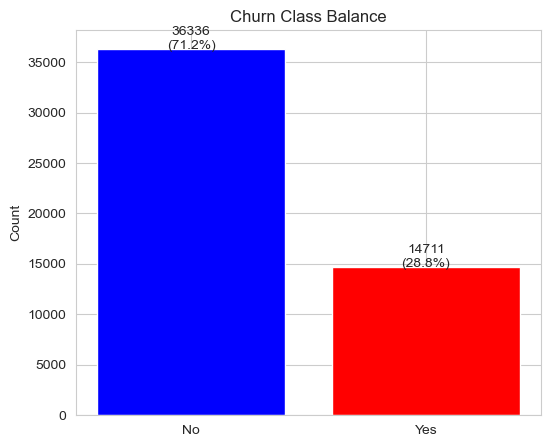

In [18]:
# Count number of customers in each churn class
churn_counts = df["Churn"].value_counts()
colors = ["blue", "red"]
# Draw bar chart
plt.figure(figsize=(6,5))
plt.bar(
    churn_counts.index,
    churn_counts.values,
    color=colors
)
# Add values and percentages above bars
for i in range(len(churn_counts)):
    plt.text(
        i,
        churn_counts.values[i],
        f'{churn_counts.values[i]}\n({churn_counts.values[i]/len(df)*100:.1f}%)',
        ha='center'
    )
# Titles
plt.title("Churn Class Balance")
plt.ylabel("Count")
plt.show()

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

In [41]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

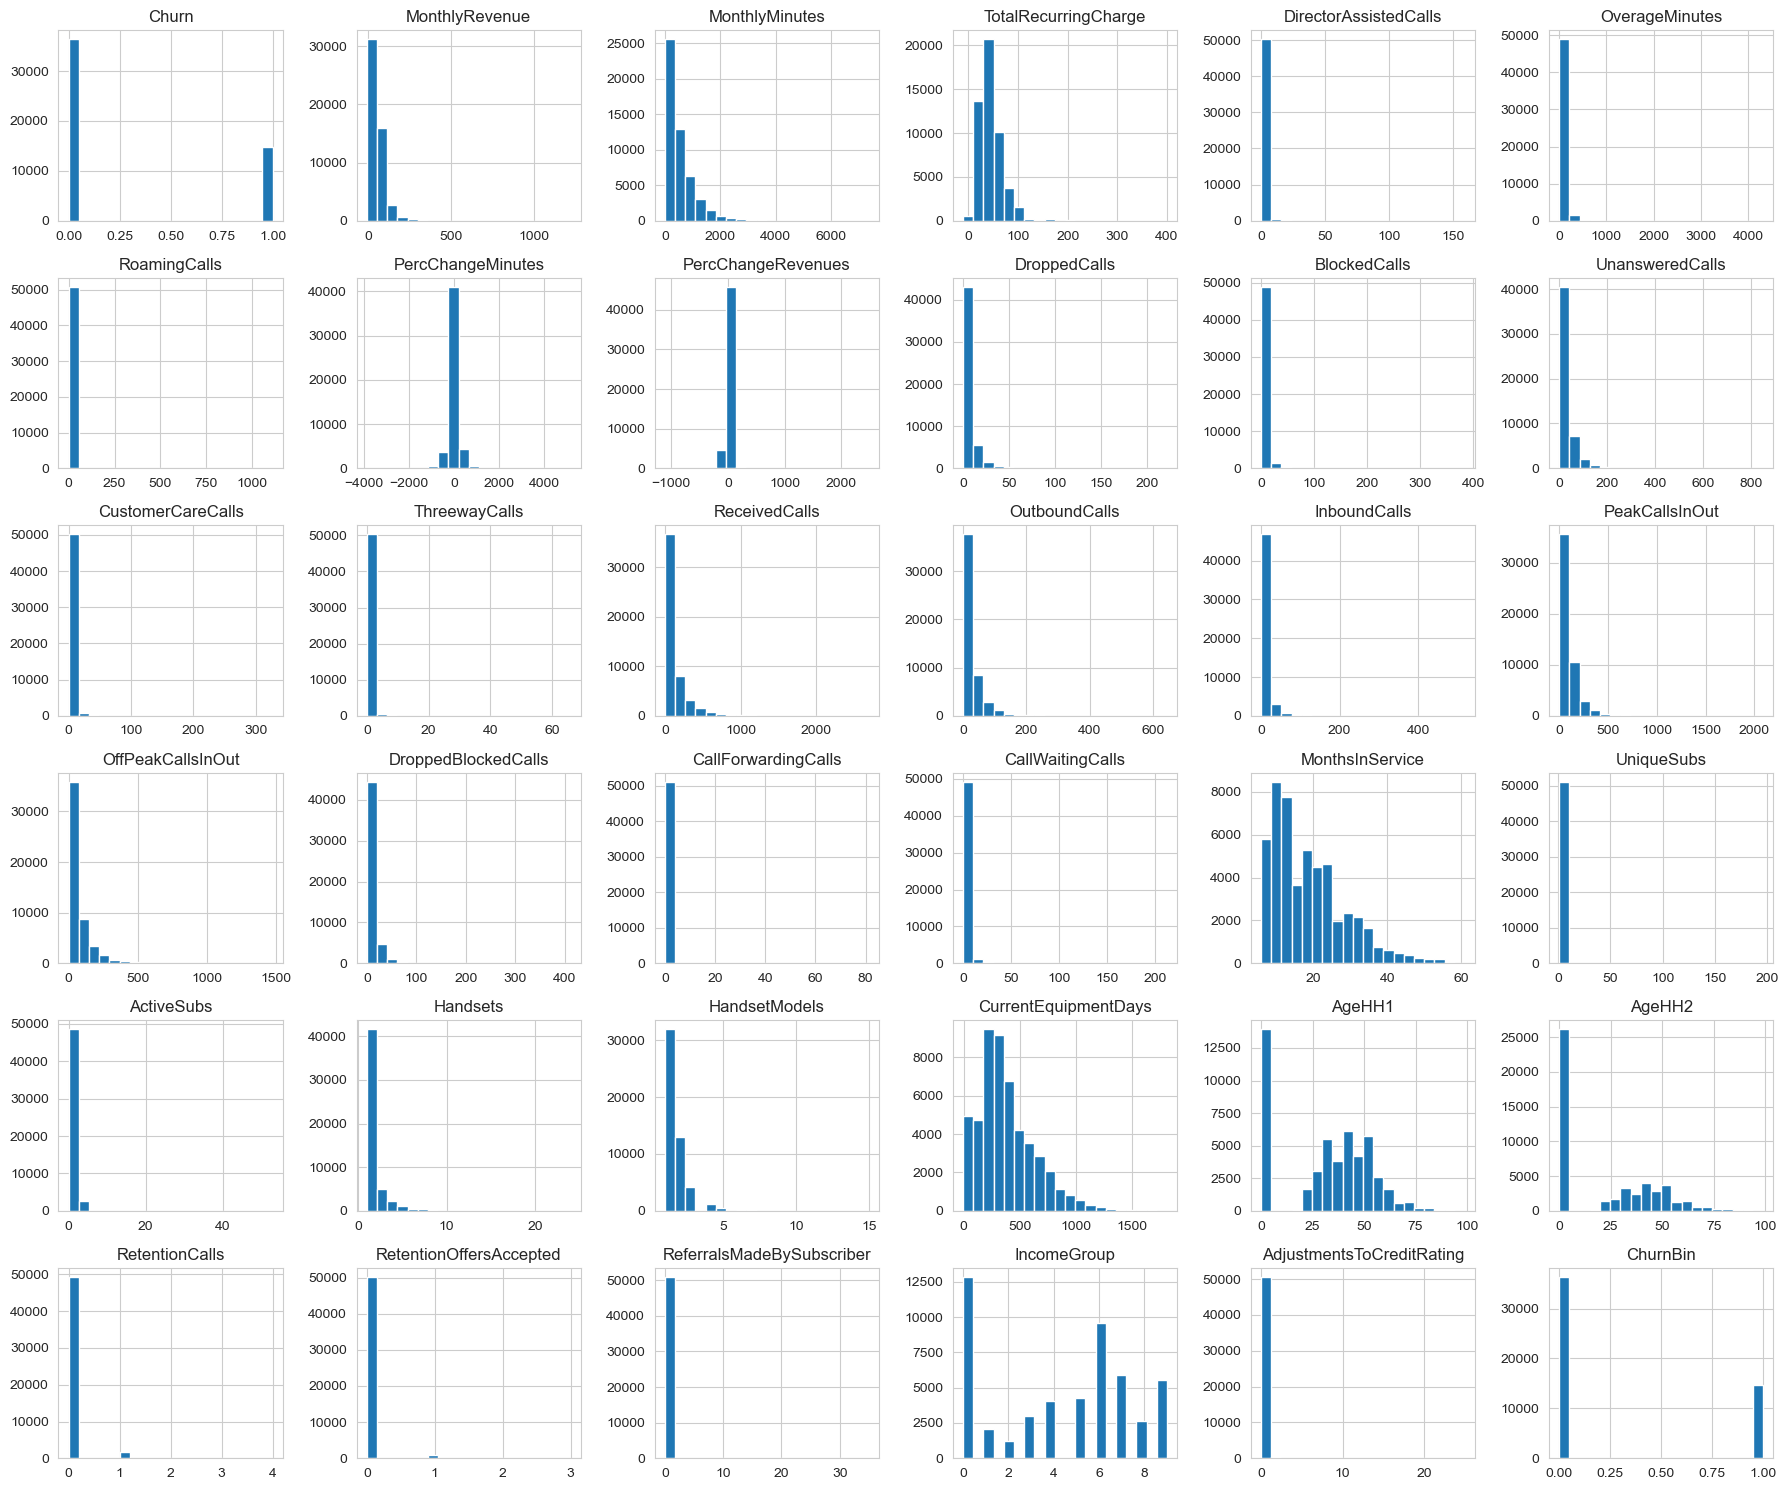

In [43]:
# Histograms for numerical columns
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(
    'CustomerID',
    errors='ignore'
)
df[numeric_cols].hist(
    figsize=(18,15),
    bins=20
)
plt.tight_layout()
plt.show()

In [ ]:
""" Most customers remained with the company, while fewer customers churned."""
###
"""
Usage Features :
Most usage features are right-skewed, meaning most customers have low values and a small number have very high values.
Examples:
MonthlyRevenue
MonthlyMinutes
ReceivedCalls
OutboundCalls

"""
###
""" 
Service Features:
Most customers have low numbers of service-related issues.
Examples:
DroppedCalls
BlockedCalls
CustomerCareCalls
UnansweredCalls

"""
###
"""
Device Features:
Most customers use a limited number of devices.
Examples:
Handsets
HandsetModels
CurrentEquipmentDays

Observation:
Device usage differs among customers."""
###
"""
Demographic Features

Age variables appear more balanced than usage variables.
Examples:
AgeHH1
AgeHH2
IncomeGroup

Observation:
Customer age and income may affect behavior."""
###
"""
Outliers
Some features contain extreme values.
Examples:
OverageMinutes
MonthlyMinutes
CurrentEquipmentDays

Observation:
Outliers may need treatment before modeling."""


'Outliers\nSome features contain extreme values.\nExamples:\nOverageMinutes\nMonthlyMinutes\nCurrentEquipmentDays\n\nObservation:\nOutliers may need treatment before modeling.'

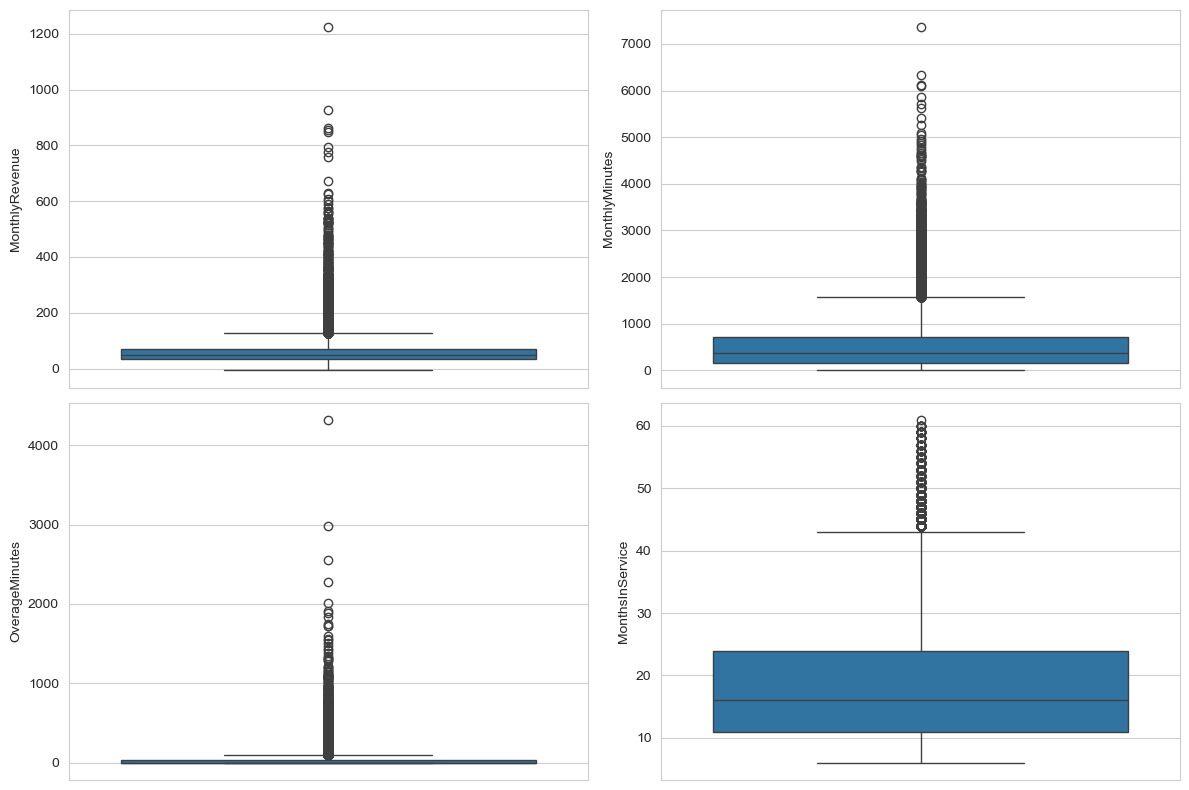

In [ ]:
cols = [
'MonthlyRevenue',
'MonthlyMinutes',
'OverageMinutes',
'MonthsInService'
]
plt.figure(figsize=(12,8))

for i,col in enumerate(cols):

    plt.subplot(2,2,i+1)

    sns.boxplot(
        y=df[col]
    )
plt.tight_layout()
plt.show()

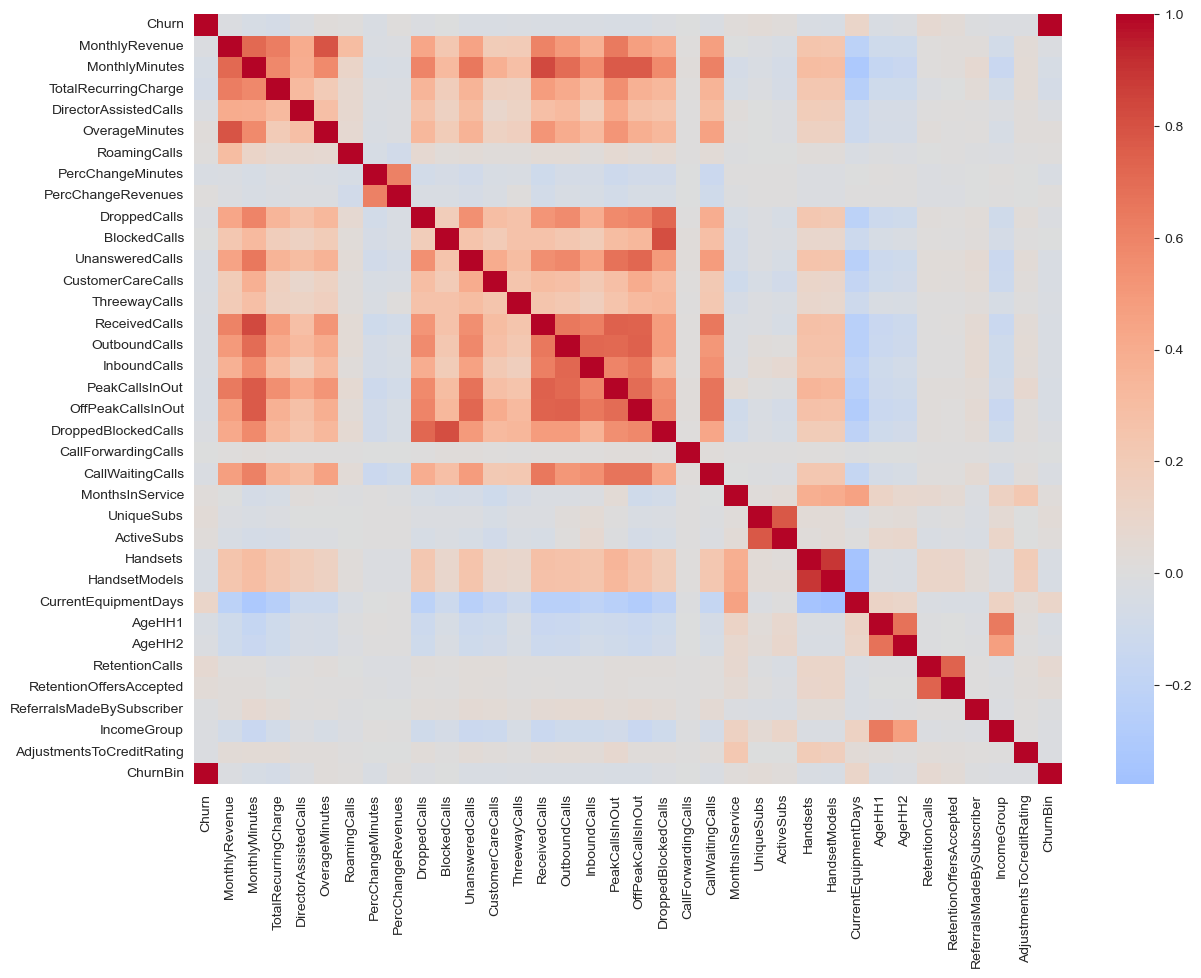

In [ ]:
# bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

corr = df[numeric_cols].corr()
plt.figure(
    figsize=(14,10)
)
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)
plt.show()

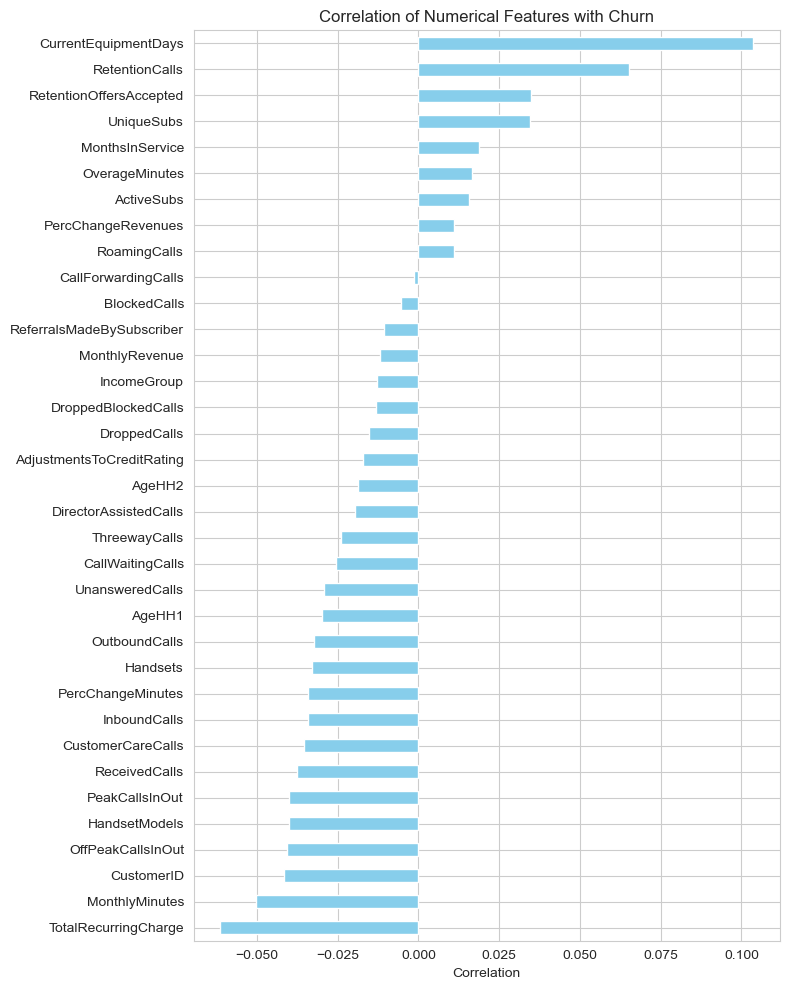

In [25]:
# Encode target
df["ChurnBin"] = (df["Churn"] == "Yes").astype(int)

# Correlation with Churn
corr = (
    df
    .select_dtypes(include="number")
    .corr()["ChurnBin"]
    .drop("ChurnBin")
)

# Sort
corr = corr.sort_values()

# Visualize
plt.figure(figsize=(8,10))

corr.plot(
    kind="barh",
    color="skyblue"
)

plt.title(
    "Correlation of Numerical Features with Churn"
)

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

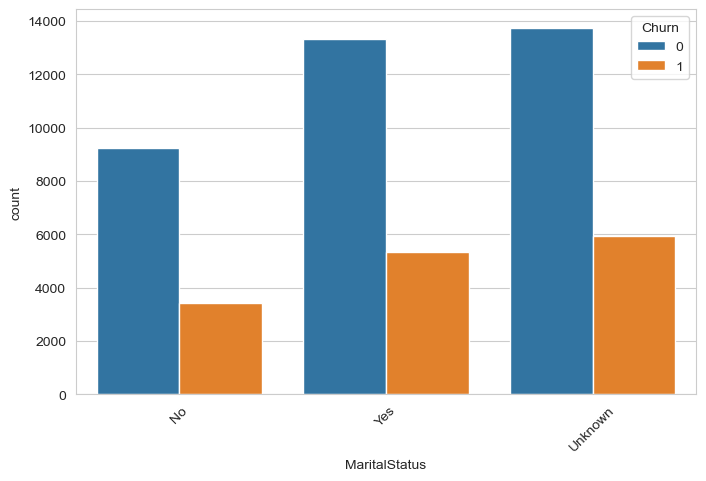

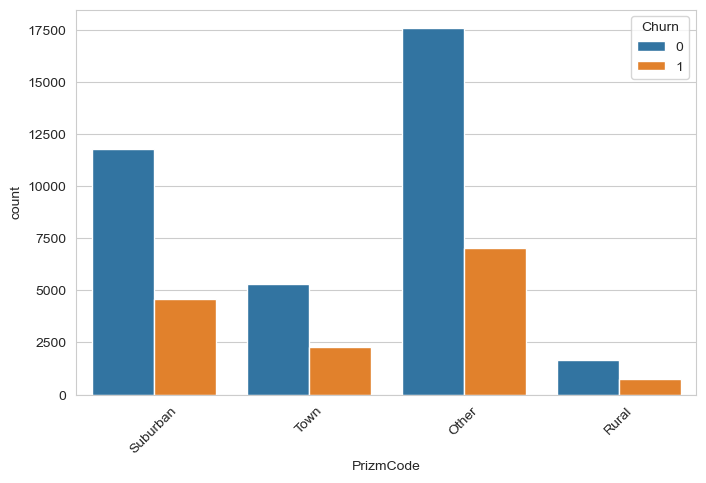

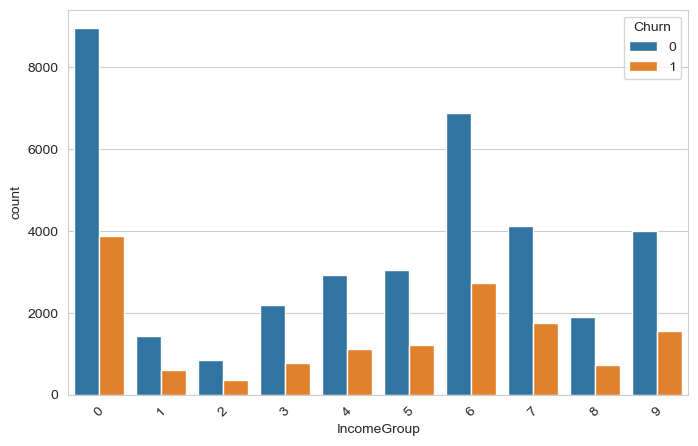

In [ ]:
cat_cols = [
'MaritalStatus',
'PrizmCode',
'IncomeGroup'
]
for col in cat_cols:

    plt.figure(
        figsize=(8,5)
    )
    sns.countplot(
        x=col,
        hue='Churn',
        data=df
    )
    plt.xticks(
        rotation=45
    )
    plt.show()

In [56]:
# Document any initial insights or hypotheses from exploration.
initial_insights = [
    "Insight 1: Churn distribution is imbalanced, with far more retained customers than churned customers.",
    "Insight 2: Most numerical features are right-skewed, meaning most customers have low values while few customers have very high values.",
    "Insight 3: Several variables contain outliers such as MonthlyRevenue, MonthlyMinutes, OverageMinutes, and CurrentEquipmentDays.",
    "Insight 4: Usage-related features such as MonthlyMinutes, ReceivedCalls, and PeakCallsInOut show moderate to strong positive correlations.",
    "Insight 5: Most customers reported low numbers of service issues such as CustomerCareCalls and DroppedCalls.",
    "Insight 6: Churn appears to depend on multiple variables rather than one single feature.",

    "Hypothesis 1: Customers with higher usage may generate higher monthly revenue.",
    "Hypothesis 2: Customers with shorter service duration (MonthsInService) may be more likely to churn.",
    "Hypothesis 3: Customers who contact customer care more frequently may have higher churn probability.",
    "Hypothesis 4: Customers experiencing more dropped or blocked calls may be less satisfied and more likely to leave.",
    "Hypothesis 5: Device-related factors such as CurrentEquipmentDays and Handsets may influence churn behavior."
]
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")


1. Insight 1: Churn distribution is imbalanced, with far more retained customers than churned customers.
2. Insight 2: Most numerical features are right-skewed, meaning most customers have low values while few customers have very high values.
3. Insight 3: Several variables contain outliers such as MonthlyRevenue, MonthlyMinutes, OverageMinutes, and CurrentEquipmentDays.
4. Insight 4: Usage-related features such as MonthlyMinutes, ReceivedCalls, and PeakCallsInOut show moderate to strong positive correlations.
5. Insight 5: Most customers reported low numbers of service issues such as CustomerCareCalls and DroppedCalls.
6. Insight 6: Churn appears to depend on multiple variables rather than one single feature.
7. Hypothesis 1: Customers with higher usage may generate higher monthly revenue.
8. Hypothesis 2: Customers with shorter service duration (MonthsInService) may be more likely to churn.
9. Hypothesis 3: Customers who contact customer care more frequently may have higher churn pro

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [50]:
# Check for missing values.

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== Missing Values Report ===")
print(missing_report)
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
                       Missing Count  Missing %
AgeHH1                           909   1.780712
AgeHH2                           909   1.780712
PercChangeMinutes                367   0.718945
PercChangeRevenues               367   0.718945
MonthlyRevenue                   156   0.305601
MonthlyMinutes                   156   0.305601
TotalRecurringCharge             156   0.305601
DirectorAssistedCalls            156   0.305601
OverageMinutes                   156   0.305601
RoamingCalls                     156   0.305601
ServiceArea                       24   0.047015
Handsets                           1   0.001959
HandsetModels                      1   0.001959
CurrentEquipmentDays               1   0.001959

Total columns with missing values: 14


In [51]:
# Check for duplicate records.

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
   print("\nSample of duplicate rows:")
   print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


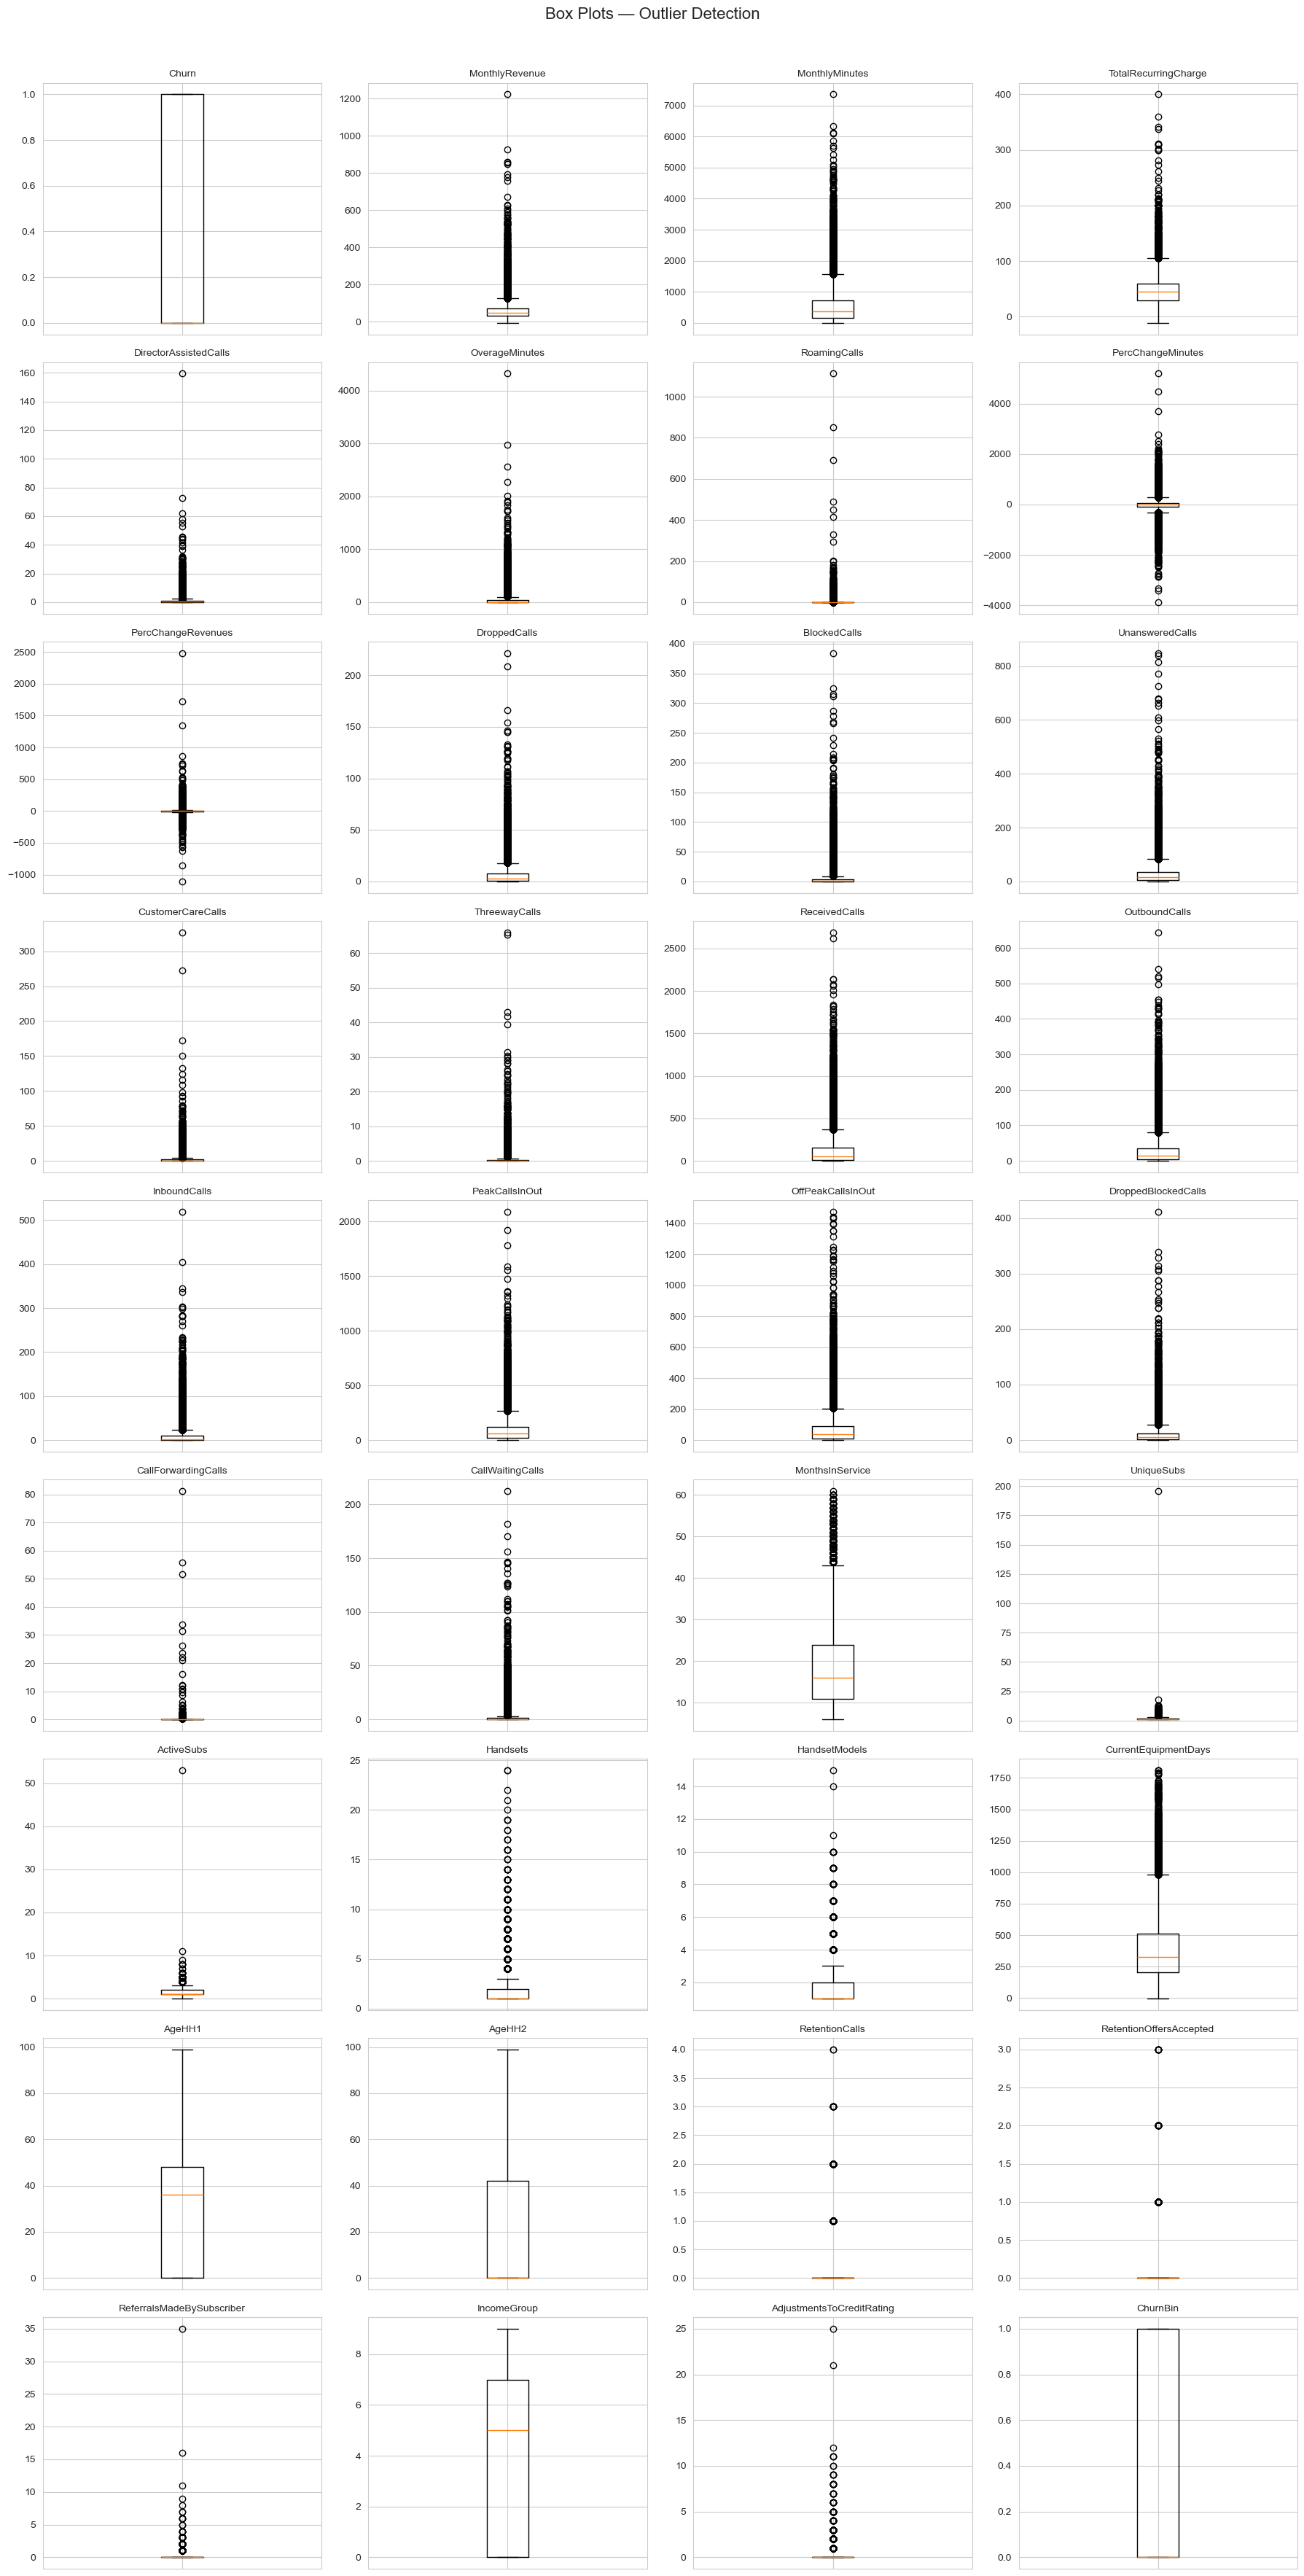

9

In [55]:
# Detect outliers using box plots for all numerical columns

import math
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 4 * n_rows)
)
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Box Plots — Outlier Detection", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
n_rows

In [54]:
# Inconsistencies (Data types + sample values)
print("Data Types:")
print(df.dtypes)

print("Unique values in Churn column:")
print(df['Churn'].unique())

Data Types:
CustomerID                     int64
Churn                          int64
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea               